# 01 — NetCDF & Xarray Fundamentals
## จาก Atmospheric Data Cube สู่แผนที่อากาศและการเลือกข้อมูลเชิงพิกัด

**กลุ่มผู้เรียน:** นิสิตปริญญาตรีชั้นปีที่ 3–4 ด้านสิ่งแวดล้อม ภูมิศาสตร์ และภูมิสารสนเทศ  
**Platform:** Google Colab + Google Drive  
**ข้อมูลหลัก:** ERA5 EVENT teaching dataset  
**บทก่อนหน้า:** Notebook 00 — Download, Setup & ERA5 Data Audit

```text
Dataset
  ↓
DataArray
  ↓
select time / level
  ↓
2-D atmospheric field
  ↓
map
  ↓
point extraction
```

หลักสำคัญของบทนี้คือ **เข้าใจโครงสร้างข้อมูลก่อนการ plot และเชื่อมทุก operation กลับไปยังความหมายทางภูมิศาสตร์**

# Learning Objectives

เมื่อจบบทนี้ นิสิตควรสามารถ:

1. อธิบายโครงสร้าง NetCDF และ Xarray `Dataset`
2. แยก `Dataset`, `DataArray`, `dimension`, `coordinate`, `variable`, `attribute`
3. อธิบาย atmospheric data cube
4. ใช้ `.isel()` และ `.sel()`
5. เลือก time และ pressure level
6. แปลง temperature จาก Kelvin เป็น °C
7. สร้างแผนที่ 850-hPa temperature
8. ใช้ nearest-grid extraction
9. ตรวจ grid coordinate จริง
10. เปรียบเทียบหลายเวลาโดยใช้ common color scale
11. export figures และ CSV
12. อธิบายข้อจำกัดของ nearest-grid extraction

# 1. Atmospheric Data Cube

temperature สามารถเขียนเป็น:

$$
T = T(t,p,\phi,\lambda)
$$

โดย:

- $t$ = time
- $p$ = pressure level
- $\phi$ = latitude
- $\lambda$ = longitude

EVENT dataset มีโครงสร้าง:

```text
time × level × latitude × longitude
```

เมื่อเลือกหนึ่งเวลาและหนึ่ง pressure level:

```text
4-D → 2-D
```

และ 2-D field ที่เหลือคือ:

```text
latitude × longitude
```

ซึ่งสามารถ plot เป็นแผนที่ได้

# 2. Dimension Reduction

```text
4-D
time × level × latitude × longitude

เลือก 1 time
        ↓
3-D
level × latitude × longitude

เลือก 1 level
        ↓
2-D
latitude × longitude

เลือก 1 location
        ↓
scalar
```

แนวคิดนี้เป็นพื้นฐานของ Notebook 02–09

# 3. Temperature Unit

ERA5 temperature ใช้ Kelvin

$$
T_{^\circ C}
=
T_K - 273.15
$$

เราจะเก็บ source variable `t` ไว้ และสร้าง derived `DataArray` ใหม่แทนการเขียนทับข้อมูลต้นฉบับ

# 4. แผนที่หลักในบทนี้

```text
Figure 01-1  850-hPa Temperature
Figure 01-2  Temperature + Selected Thai Locations
Figure 01-3  2–5 October Temperature Evolution
Figure 01-4  Point Temperature Evolution
```

# 5. ติดตั้งไลบรารี

In [1]:
# CELL 1 — Install/check libraries

import sys
import subprocess

PACKAGES = [
    "xarray>=2025.1",
    "netCDF4>=1.7",
    "h5netcdf>=1.4",
    "dask[array]>=2025.1",
    "numpy>=1.26",
    "pandas>=2.2",
    "matplotlib>=3.8",
    "cartopy>=0.23",
]

subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "--upgrade-strategy",
        "only-if-needed",
        *PACKAGES,
    ]
)

print("Libraries ready.")

Libraries ready.


# 6. Mount Google Drive

In [2]:
# CELL 2 — Mount Google Drive

from pathlib import Path
from google.colab import drive

drive.mount(
    "/content/drive",
    force_remount=False,
)

DRIVE_ROOT = Path(
    "/content/drive/MyDrive"
)

print("Google Drive mounted:", DRIVE_ROOT)

Mounted at /content/drive
Google Drive mounted: /content/drive/MyDrive


# 7. Import libraries

In [3]:
# CELL 3 — Imports

from __future__ import annotations

import json
import sys

from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from IPython.display import display

print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("Xarray:", xr.__version__)

Python: 3.13.15
NumPy: 2.1.3
pandas: 2.2.3
Xarray: 2025.12.0


# 8. Course Paths

Notebook 00 ดาวน์โหลดข้อมูลไว้ใน:

```text
MyDrive/
Teaching_ERA5_Reanalysis_GIS/
└── 00_source_github/
```

Notebook 01 จะไม่ดาวน์โหลดข้อมูลซ้ำ

In [4]:
# CELL 4 — Course paths

COURSE_ROOT = (
    DRIVE_ROOT
    / "Teaching_ERA5_Reanalysis_GIS"
)

SOURCE_GITHUB_DIR = (
    COURSE_ROOT
    / "00_source_github"
)

METADATA_DIR = (
    COURSE_ROOT
    / "02_metadata"
)

OUTPUT_DIR = (
    COURSE_ROOT
    / "03_output"
)

FIGURE_DIR = (
    COURSE_ROOT
    / "04_figures"
    / "01"
)

for folder in [
    METADATA_DIR,
    OUTPUT_DIR,
    FIGURE_DIR,
]:
    folder.mkdir(
        parents=True,
        exist_ok=True,
    )

EVENT_FILE = (
    SOURCE_GITHUB_DIR
    / "era5_noul_20111002_05_SEAsia_pressure_levels_0.5deg.nc"
)

if not EVENT_FILE.exists():
    raise FileNotFoundError(
        "EVENT teaching dataset not found. Run Notebook 00 first."
    )

print("EVENT file:", EVENT_FILE)
print(
    "Size:",
    f"{EVENT_FILE.stat().st_size / (1024**2):.2f} MB",
)

EVENT file: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/00_source_github/era5_noul_20111002_05_SEAsia_pressure_levels_0.5deg.nc
Size: 10.05 MB


# 9. เปิด EVENT Dataset

In [5]:
# CELL 5 — Open EVENT dataset

ds = xr.open_dataset(
    EVENT_FILE,
    decode_times=True,
)

print(ds)

<xarray.Dataset> Size: 14MB
Dimensions:    (time: 4, level: 8, latitude: 100, longitude: 140)
Coordinates:
  * time       (time) datetime64[ns] 32B 2011-10-02 2011-10-03 ... 2011-10-05
  * level      (level) int32 32B 200 250 300 500 700 850 925 1000
  * latitude   (latitude) float32 400B 44.88 44.38 43.88 ... -4.125 -4.625
  * longitude  (longitude) float32 560B 60.12 60.62 61.12 ... 128.6 129.1 129.6
Data variables:
    d          (time, level, latitude, longitude) float32 2MB ...
    z          (time, level, latitude, longitude) float32 2MB ...
    r          (time, level, latitude, longitude) float32 2MB ...
    q          (time, level, latitude, longitude) float32 2MB ...
    t          (time, level, latitude, longitude) float32 2MB ...
    u          (time, level, latitude, longitude) float32 2MB ...
    v          (time, level, latitude, longitude) float32 2MB ...
    vo         (time, level, latitude, longitude) float32 2MB ...
Attributes: (12/17)
    Conventions:              

# 10. Dataset, DataArray, Dimension, Coordinate และ Attribute

ให้สังเกต 4 ส่วนหลัก:

```text
Dimensions
Coordinates
Data variables
Attributes
```

`ds` คือ `Dataset` ส่วน `ds["t"]` คือ `DataArray`

In [6]:
# CELL 6 — Dataset inventory

DATASET_INVENTORY = pd.DataFrame(
    [
        {
            "category": "dimensions",
            "value": json.dumps(
                {
                    key: int(value)
                    for key, value in ds.sizes.items()
                }
            ),
        },
        {
            "category": "coordinates",
            "value": ",".join(ds.coords),
        },
        {
            "category": "data_variables",
            "value": ",".join(ds.data_vars),
        },
    ]
)

display(DATASET_INVENTORY)

,category,value
0,dimensions,"{""time"": 4, ""level"": 8, ""latitude"": 100, ""long..."
1,coordinates,"longitude,latitude,level,time"
2,data_variables,"d,z,r,q,t,u,v,vo"


In [7]:
# CELL 7 — Dataset vs DataArray

temperature_K = ds["t"]

print("Dataset object:", type(ds))
print("Temperature object:", type(temperature_K))
print()
print(temperature_K)

Dataset object: <class 'xarray.core.dataset.Dataset'>
Temperature object: <class 'xarray.core.dataarray.DataArray'>

<xarray.DataArray 't' (time: 4, level: 8, latitude: 100, longitude: 140)> Size: 2MB
[448000 values with dtype=float32]
Coordinates:
  * time       (time) datetime64[ns] 32B 2011-10-02 2011-10-03 ... 2011-10-05
  * level      (level) int32 32B 200 250 300 500 700 850 925 1000
  * latitude   (latitude) float32 400B 44.88 44.38 43.88 ... -4.125 -4.625
  * longitude  (longitude) float32 560B 60.12 60.62 61.12 ... 128.6 129.1 129.6
Attributes:
    units:          K
    long_name:      Temperature
    standard_name:  air_temperature


In [8]:
# CELL 8 — Temperature metadata

TEMPERATURE_METADATA = pd.DataFrame(
    [
        {
            "attribute": key,
            "value": str(value),
        }
        for key, value in temperature_K.attrs.items()
    ]
)

display(TEMPERATURE_METADATA)

print("Dimensions:", temperature_K.dims)
print("Shape:", temperature_K.shape)
print("dtype:", temperature_K.dtype)

,attribute,value
0,units,K
1,long_name,Temperature
2,standard_name,air_temperature


Dimensions: ('time', 'level', 'latitude', 'longitude')
Shape: (4, 8, 100, 140)
dtype: float32


# 11. `.isel()` — Index Selection

`.isel()` เลือกด้วย index

```python
ds["t"].isel(
    time=0,
    level=5,
)
```

ต้องตรวจ coordinate จริงภายหลังว่า index นั้นตรงกับเวลาและ pressure level ใด

In [9]:
# CELL 9 — Index selection with .isel()

t_isel = (
    ds["t"]
    .isel(
        time=0,
        level=5,
    )
)

print(t_isel)
print()
print(
    "Selected time:",
    pd.to_datetime(
        t_isel["time"].values
    ),
)
print(
    "Selected pressure level:",
    float(
        t_isel["level"].values
    ),
    "hPa",
)

<xarray.DataArray 't' (latitude: 100, longitude: 140)> Size: 56kB
[14000 values with dtype=float32]
Coordinates:
  * latitude   (latitude) float32 400B 44.88 44.38 43.88 ... -4.125 -4.625
  * longitude  (longitude) float32 560B 60.12 60.62 61.12 ... 128.6 129.1 129.6
    level      int32 4B 850
    time       datetime64[ns] 8B 2011-10-02
Attributes:
    units:          K
    long_name:      Temperature
    standard_name:  air_temperature

Selected time: 2011-10-02 00:00:00
Selected pressure level: 850.0 hPa


# 12. `.sel()` — Coordinate Selection

`.sel()` เลือกด้วย coordinate โดยตรง

```python
ds["t"].sel(
    time="2011-10-02",
    level=850,
)
```

จึงอ่านง่ายกว่าและเหมาะกับ atmospheric analysis

In [10]:
# CELL 10 — Coordinate selection with .sel()

t_850_K = (
    ds["t"]
    .sel(
        time="2011-10-02",
        level=850,
    )
)

print(t_850_K)
print()
print("Dimensions after selection:", t_850_K.dims)
print("Shape:", t_850_K.shape)

<xarray.DataArray 't' (latitude: 100, longitude: 140)> Size: 56kB
[14000 values with dtype=float32]
Coordinates:
  * latitude   (latitude) float32 400B 44.88 44.38 43.88 ... -4.125 -4.625
  * longitude  (longitude) float32 560B 60.12 60.62 61.12 ... 128.6 129.1 129.6
    level      int32 4B 850
    time       datetime64[ns] 8B 2011-10-02
Attributes:
    units:          K
    long_name:      Temperature
    standard_name:  air_temperature

Dimensions after selection: ('latitude', 'longitude')
Shape: (100, 140)


ตอนนี้ field ลดเหลือ:

```text
latitude × longitude
```

จึงพร้อมแสดงเป็นแผนที่

# 13. แปลง Kelvin เป็น Celsius

In [11]:
# CELL 11 — Convert Kelvin to Celsius

t_850_C = (
    t_850_K
    - 273.15
)

t_850_C.name = "temperature_C"

t_850_C.attrs = {
    "long_name": "850-hPa air temperature",
    "units": "degC",
    "derived_from": "ERA5 t in Kelvin",
}

print(t_850_C)

<xarray.DataArray 'temperature_C' (latitude: 100, longitude: 140)> Size: 56kB
array([[ 7.96286  ,  9.34314  , 10.705292 , ..., -6.0078125, -6.271942 ,
        -6.5718384],
       [ 8.954071 , 10.403015 , 11.679352 , ..., -5.8309326, -6.547516 ,
        -6.8469543],
       [10.130768 , 11.504395 , 12.817902 , ..., -5.7817993, -6.321045 ,
        -6.788788 ],
       ...,
       [17.012177 , 17.033142 , 17.248657 , ..., 18.186005 , 17.745453 ,
        17.373566 ],
       [17.107056 , 17.214325 , 17.01883  , ..., 17.807434 , 17.22052  ,
        17.352112 ],
       [16.912048 , 17.425049 , 16.991669 , ..., 17.702545 , 17.39978  ,
        17.375    ]], dtype=float32)
Coordinates:
  * latitude   (latitude) float32 400B 44.88 44.38 43.88 ... -4.125 -4.625
  * longitude  (longitude) float32 560B 60.12 60.62 61.12 ... 128.6 129.1 129.6
    level      int32 4B 850
    time       datetime64[ns] 8B 2011-10-02
Attributes:
    long_name:     850-hPa air temperature
    units:         degC
    derived

# 14. Figure 01-1 — 850-hPa Temperature Map

/usr/local/lib/python3.13/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.13/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


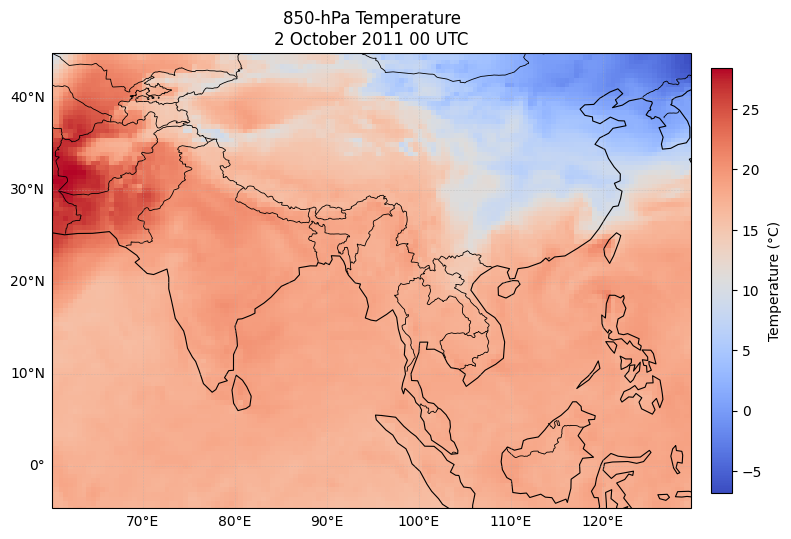

Saved: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/04_figures/01/01_01_850hPa_temperature_20111002_00UTC.png


In [12]:
# CELL 12 — 850-hPa temperature map

fig = plt.figure(
    figsize=(10, 6.5)
)

ax = plt.axes(
    projection=ccrs.PlateCarree()
)

mesh = ax.pcolormesh(
    t_850_C["longitude"],
    t_850_C["latitude"],
    t_850_C,
    transform=ccrs.PlateCarree(),
    shading="auto",
    cmap="coolwarm",
)

ax.coastlines(
    resolution="110m",
    linewidth=0.8,
)

ax.add_feature(
    cfeature.BORDERS,
    linewidth=0.6,
)

gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.4,
    alpha=0.5,
    linestyle="--",
)

gl.top_labels = False
gl.right_labels = False

ax.set_extent(
    [
        float(t_850_C["longitude"].min()),
        float(t_850_C["longitude"].max()),
        float(t_850_C["latitude"].min()),
        float(t_850_C["latitude"].max()),
    ],
    crs=ccrs.PlateCarree(),
)

cbar = plt.colorbar(
    mesh,
    ax=ax,
    pad=0.025,
    shrink=0.85,
)

cbar.set_label(
    "Temperature (°C)"
)

ax.set_title(
    "850-hPa Temperature\n"
    "2 October 2011 00 UTC"
)

FIG_01_01 = (
    FIGURE_DIR
    / "01_01_850hPa_temperature_20111002_00UTC.png"
)

plt.savefig(
    FIG_01_01,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:", FIG_01_01)

# 15. อ่านแผนที่อย่างไร?

ก่อนตีความเชิง synoptic ให้ตอบ:

1. temperature มีช่วงประมาณเท่าไร?
2. บริเวณใดอุ่นกว่า/เย็นกว่า?
3. มี spatial gradient บริเวณใด?
4. ประเทศไทยอยู่ส่วนใดของ field?

เป้าหมายของ Notebook 01 คือ **อ่าน field ให้ถูกก่อนตีความกลไก**

In [13]:
# CELL 13 — Descriptive statistics

TEMPERATURE_STATS = pd.DataFrame(
    {
        "statistic": [
            "minimum",
            "mean",
            "median",
            "maximum",
        ],
        "temperature_C": [
            float(t_850_C.min()),
            float(t_850_C.mean()),
            float(t_850_C.median()),
            float(t_850_C.max()),
        ],
    }
)

display(TEMPERATURE_STATS)

,statistic,temperature_C
0,minimum,-6.846954
1,mean,15.932498
2,median,17.565948
3,maximum,28.434418


# 16. Nearest-Grid Extraction

ตำแหน่งเมืองจริงมักไม่ตรง ERA5 grid center

จึงใช้:

```python
.sel(
    latitude=...,
    longitude=...,
    method="nearest",
)
```

แต่:

> **nearest grid value ≠ station observation**

In [14]:
# CELL 14 — Example locations

LOCATIONS = {
    "Bangkok": {
        "latitude": 13.7563,
        "longitude": 100.5018,
    },
    "Chiang Mai": {
        "latitude": 18.7883,
        "longitude": 98.9853,
    },
    "Nakhon Ratchasima": {
        "latitude": 14.9799,
        "longitude": 102.0977,
    },
}

LOCATIONS_DF = pd.DataFrame(
    [
        {
            "location": name,
            **coords,
        }
        for name, coords in LOCATIONS.items()
    ]
)

display(LOCATIONS_DF)

,location,latitude,longitude
0,Bangkok,13.7563,100.5018
1,Chiang Mai,18.7883,98.9853
2,Nakhon Ratchasima,14.9799,102.0977


In [15]:
# CELL 15 — Nearest-grid extraction

point_rows = []

for name, coords in LOCATIONS.items():
    point = (
        t_850_C
        .sel(
            latitude=coords["latitude"],
            longitude=coords["longitude"],
            method="nearest",
        )
    )

    point_rows.append(
        {
            "location": name,
            "requested_latitude": coords["latitude"],
            "requested_longitude": coords["longitude"],
            "selected_grid_latitude": float(
                point["latitude"].values
            ),
            "selected_grid_longitude": float(
                point["longitude"].values
            ),
            "temperature_C": float(
                point.values
            ),
        }
    )

POINT_EXTRACTION = pd.DataFrame(
    point_rows
)

display(POINT_EXTRACTION)

,location,requested_latitude,requested_longitude,selected_grid_latitude,selected_grid_longitude,temperature_C
0,Bangkok,13.7563,100.5018,13.875,100.625,17.578583
1,Chiang Mai,18.7883,98.9853,18.875,99.125,17.355438
2,Nakhon Ratchasima,14.9799,102.0977,14.875,102.125,17.952850


# 17. Requested Location ≠ Selected Grid Center

จากตารางให้เปรียบเทียบ:

```text
requested coordinates
vs
selected grid coordinates
```

นี่เป็นพื้นฐานของ spatial matching ระหว่าง reanalysis กับ station data

# 18. Figure 01-2 — Temperature Map with Selected Locations

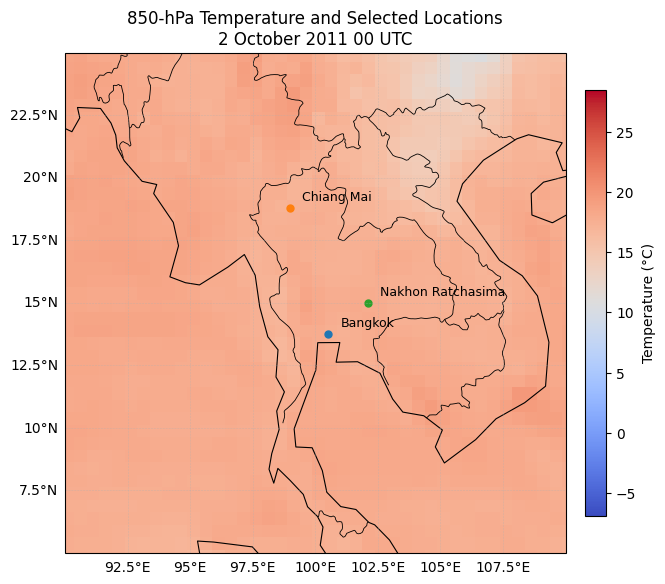

Saved: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/04_figures/01/01_02_850hPa_temperature_selected_locations.png


In [16]:
# CELL 16 — Map with selected locations

fig = plt.figure(
    figsize=(10, 6.5)
)

ax = plt.axes(
    projection=ccrs.PlateCarree()
)

mesh = ax.pcolormesh(
    t_850_C["longitude"],
    t_850_C["latitude"],
    t_850_C,
    transform=ccrs.PlateCarree(),
    shading="auto",
    cmap="coolwarm",
)

ax.coastlines(
    resolution="110m",
    linewidth=0.8,
)

ax.add_feature(
    cfeature.BORDERS,
    linewidth=0.6,
)

for name, coords in LOCATIONS.items():
    ax.plot(
        coords["longitude"],
        coords["latitude"],
        marker="o",
        markersize=5,
        transform=ccrs.PlateCarree(),
    )

    ax.text(
        coords["longitude"] + 0.5,
        coords["latitude"] + 0.3,
        name,
        fontsize=9,
        transform=ccrs.PlateCarree(),
    )

ax.set_extent(
    [90, 110, 5, 25],
    crs=ccrs.PlateCarree(),
)

gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.4,
    alpha=0.5,
    linestyle="--",
)

gl.top_labels = False
gl.right_labels = False

cbar = plt.colorbar(
    mesh,
    ax=ax,
    pad=0.025,
    shrink=0.85,
)

cbar.set_label(
    "Temperature (°C)"
)

ax.set_title(
    "850-hPa Temperature and Selected Locations\n"
    "2 October 2011 00 UTC"
)

FIG_01_02 = (
    FIGURE_DIR
    / "01_02_850hPa_temperature_selected_locations.png"
)

plt.savefig(
    FIG_01_02,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:", FIG_01_02)

# 19. Event Times

In [17]:
# CELL 17 — Event times

event_times = pd.DatetimeIndex(
    pd.to_datetime(
        ds["time"].values
    )
)

EVENT_TIMES_DF = pd.DataFrame(
    {
        "time_index": np.arange(
            len(event_times)
        ),
        "time_UTC": event_times,
    }
)

display(EVENT_TIMES_DF)

,time_index,time_UTC
0,0,2011-10-02
1,1,2011-10-03
2,2,2011-10-04
3,3,2011-10-05


# 20. Figure 01-3 — Temperature Evolution on 2–5 October 2011

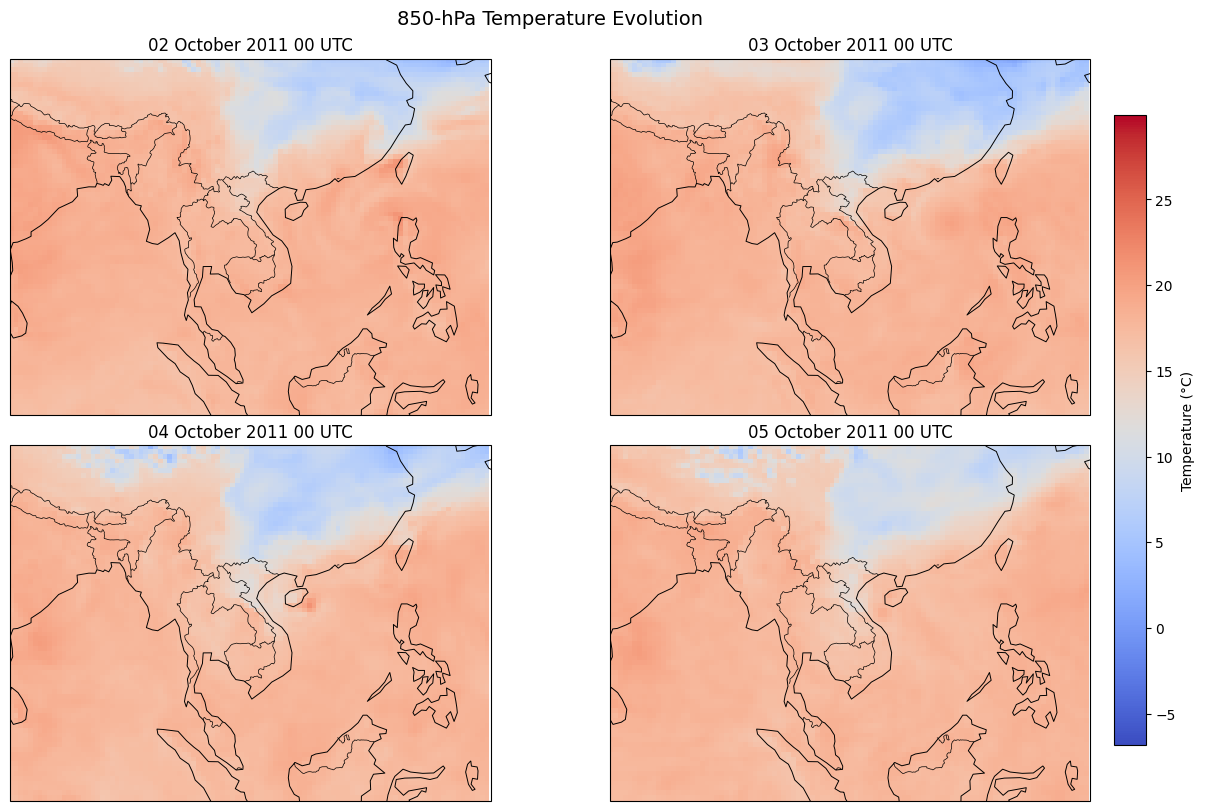

Saved: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/04_figures/01/01_03_850hPa_temperature_event_evolution.png


In [18]:
# CELL 18 — Four-date comparison

all_fields = []

for time_value in event_times:
    field_C = (
        ds["t"]
        .sel(
            time=time_value,
            level=850,
        )
        - 273.15
    )

    all_fields.append(field_C)

vmin = float(
    min(
        field.min().values
        for field in all_fields
    )
)

vmax = float(
    max(
        field.max().values
        for field in all_fields
    )
)

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(13, 8),
    subplot_kw={
        "projection": ccrs.PlateCarree()
    },
    constrained_layout=True,
)

axes = axes.ravel()

for ax, time_value, field_C in zip(
    axes,
    event_times,
    all_fields,
):
    mesh = ax.pcolormesh(
        field_C["longitude"],
        field_C["latitude"],
        field_C,
        transform=ccrs.PlateCarree(),
        shading="auto",
        cmap="coolwarm",
        vmin=vmin,
        vmax=vmax,
    )

    ax.coastlines(
        resolution="110m",
        linewidth=0.7,
    )

    ax.add_feature(
        cfeature.BORDERS,
        linewidth=0.5,
    )

    ax.set_extent(
        [80, 130, -2, 35],
        crs=ccrs.PlateCarree(),
    )

    ax.set_title(
        pd.Timestamp(
            time_value
        ).strftime(
            "%d %B %Y %H UTC"
        )
    )

cbar = fig.colorbar(
    mesh,
    ax=axes.tolist(),
    orientation="vertical",
    pad=0.02,
    shrink=0.85,
)

cbar.set_label(
    "Temperature (°C)"
)

fig.suptitle(
    "850-hPa Temperature Evolution",
    fontsize=14,
)

FIG_01_03 = (
    FIGURE_DIR
    / "01_03_850hPa_temperature_event_evolution.png"
)

plt.savefig(
    FIG_01_03,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:", FIG_01_03)

# 21. ทำไมต้องใช้ Common Color Scale?

comparative maps ควรใช้:

```text
common vmin
common vmax
common colormap
common units
```

เพื่อให้สีเดียวกันหมายถึงค่าเดียวกันในทุก panel

# 22. Figure 01-4 — Point Temperature Evolution

In [19]:
# CELL 19 — Extract point temperatures through time

point_time_rows = []

for name, coords in LOCATIONS.items():
    series_K = (
        ds["t"]
        .sel(
            level=850,
            latitude=coords["latitude"],
            longitude=coords["longitude"],
            method="nearest",
        )
    )

    series_C = (
        series_K
        - 273.15
    )

    for time_value, value in zip(
        pd.to_datetime(
            series_C["time"].values
        ),
        series_C.values,
    ):
        point_time_rows.append(
            {
                "location": name,
                "time_UTC": pd.Timestamp(
                    time_value
                ),
                "temperature_C": float(
                    value
                ),
                "selected_grid_latitude": float(
                    series_C["latitude"].values
                ),
                "selected_grid_longitude": float(
                    series_C["longitude"].values
                ),
            }
        )

POINT_TIME_SERIES = pd.DataFrame(
    point_time_rows
)

display(POINT_TIME_SERIES)

,location,time_UTC,temperature_C,selected_grid_latitude,selected_grid_longitude
0,Bangkok,2011-10-02,17.578583,13.875,100.625
1,Bangkok,2011-10-03,18.079681,13.875,100.625
2,Bangkok,2011-10-04,16.320831,13.875,100.625
3,Bangkok,2011-10-05,17.232910,13.875,100.625
4,Chiang Mai,2011-10-02,17.355438,18.875,99.125
5,Chiang Mai,2011-10-03,17.189514,18.875,99.125
6,Chiang Mai,2011-10-04,16.547791,18.875,99.125
7,Chiang Mai,2011-10-05,17.511841,18.875,99.125
8,Nakhon Ratchasima,2011-10-02,17.952850,14.875,102.125
9,Nakhon Ratchasima,2011-10-03,17.704926,14.875,102.125


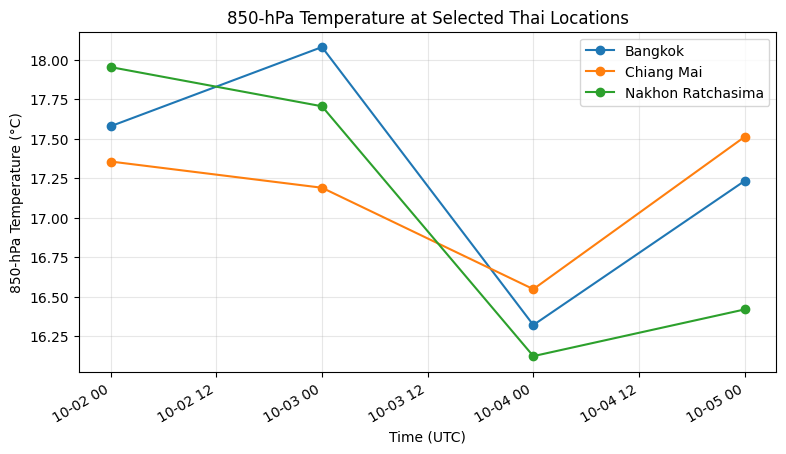

Saved: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/04_figures/01/01_04_point_temperature_evolution.png


In [20]:
# CELL 20 — Plot point temperature evolution

fig, ax = plt.subplots(
    figsize=(9, 5)
)

for name, group in (
    POINT_TIME_SERIES
    .groupby("location")
):
    ax.plot(
        group["time_UTC"],
        group["temperature_C"],
        marker="o",
        label=name,
    )

ax.set_xlabel(
    "Time (UTC)"
)

ax.set_ylabel(
    "850-hPa Temperature (°C)"
)

ax.set_title(
    "850-hPa Temperature at Selected Thai Locations"
)

ax.grid(
    True,
    alpha=0.3,
)

ax.legend()

fig.autofmt_xdate()

FIG_01_04 = (
    FIGURE_DIR
    / "01_04_point_temperature_evolution.png"
)

plt.savefig(
    FIG_01_04,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:", FIG_01_04)

# 23. ระวังการตีความ Point Extraction

ค่าที่ได้คือ:

> **ERA5 teaching-grid value nearest to the requested location**

ไม่ใช่ station observation

และ 850-hPa temperature ไม่ใช่ surface temperature

# 24. Spatial Slicing เบื้องต้น

Notebook 02 จะเรียน spatial subsetting อย่างละเอียด

ในบทนี้ทดลอง:

```python
subset = field.sel(
    latitude=slice(25, 5),
    longitude=slice(90, 110),
)
```

latitude ของ ERA5 ในชุดนี้เรียงจากเหนือไปใต้ จึงต้องตรวจ coordinate ordering ก่อน selection

In [21]:
# CELL 21 — Simple spatial subset

thai_region_C = (
    t_850_C
    .sel(
        latitude=slice(
            25,
            5,
        ),
        longitude=slice(
            90,
            110,
        ),
    )
)

print(thai_region_C)
print(
    "Subset shape:",
    thai_region_C.shape,
)

<xarray.DataArray 'temperature_C' (latitude: 40, longitude: 40)> Size: 6kB
array([[18.628448, 18.708069, 18.340942, ..., 15.803528, 16.047638,
        16.04715 ],
       [18.744324, 18.794373, 18.722382, ..., 16.007599, 16.207367,
        16.402374],
       [18.796295, 19.084747, 18.918823, ..., 16.271729, 16.57306 ,
        16.886292],
       ...,
       [17.728302, 17.660583, 17.69635 , ..., 17.711609, 17.816986,
        17.87323 ],
       [17.83603 , 17.736877, 17.71637 , ..., 17.64914 , 17.721619,
        17.650574],
       [17.766907, 17.664398, 17.652008, ..., 17.664398, 17.567627,
        17.404572]], dtype=float32)
Coordinates:
  * latitude   (latitude) float32 160B 24.88 24.38 23.88 ... 6.375 5.875 5.375
  * longitude  (longitude) float32 160B 90.12 90.62 91.12 ... 108.6 109.1 109.6
    level      int32 4B 850
    time       datetime64[ns] 8B 2011-10-02
Attributes:
    long_name:     850-hPa air temperature
    units:         degC
    derived_from:  ERA5 t in Kelvin
Subset sha

# 25. Export Outputs

In [22]:
# CELL 22 — Export analysis tables

POINT_EXTRACTION_CSV = (
    OUTPUT_DIR
    / "01_point_extraction_850hPa_temperature.csv"
)

POINT_TIME_SERIES_CSV = (
    OUTPUT_DIR
    / "01_point_temperature_evolution.csv"
)

VARIABLE_METADATA_CSV = (
    METADATA_DIR
    / "01_event_variable_metadata.csv"
)

POINT_EXTRACTION.to_csv(
    POINT_EXTRACTION_CSV,
    index=False,
)

POINT_TIME_SERIES.to_csv(
    POINT_TIME_SERIES_CSV,
    index=False,
)

variable_metadata_rows = []

for variable_name in ds.data_vars:
    variable = ds[
        variable_name
    ]

    variable_metadata_rows.append(
        {
            "variable": variable_name,
            "long_name": variable.attrs.get(
                "long_name",
                "",
            ),
            "standard_name": variable.attrs.get(
                "standard_name",
                "",
            ),
            "units": variable.attrs.get(
                "units",
                "",
            ),
            "dimensions": ",".join(
                variable.dims
            ),
            "dtype": str(
                variable.dtype
            ),
        }
    )

VARIABLE_METADATA = pd.DataFrame(
    variable_metadata_rows
)

VARIABLE_METADATA.to_csv(
    VARIABLE_METADATA_CSV,
    index=False,
)

print("Saved:", POINT_EXTRACTION_CSV)
print("Saved:", POINT_TIME_SERIES_CSV)
print("Saved:", VARIABLE_METADATA_CSV)

Saved: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/03_output/01_point_extraction_850hPa_temperature.csv
Saved: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/03_output/01_point_temperature_evolution.csv
Saved: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/02_metadata/01_event_variable_metadata.csv


# 26. Figure Manifest

In [23]:
# CELL 23 — Figure manifest

FIGURE_MANIFEST = pd.DataFrame(
    [
        {
            "figure": "01-01",
            "file": str(FIG_01_01),
            "description": (
                "850-hPa temperature map"
            ),
        },
        {
            "figure": "01-02",
            "file": str(FIG_01_02),
            "description": (
                "850-hPa temperature map with selected Thai locations"
            ),
        },
        {
            "figure": "01-03",
            "file": str(FIG_01_03),
            "description": (
                "850-hPa temperature comparison for 2–5 October 2011"
            ),
        },
        {
            "figure": "01-04",
            "file": str(FIG_01_04),
            "description": (
                "850-hPa point temperature evolution"
            ),
        },
    ]
)

FIGURE_MANIFEST_CSV = (
    METADATA_DIR
    / "01_figure_manifest.csv"
)

FIGURE_MANIFEST.to_csv(
    FIGURE_MANIFEST_CSV,
    index=False,
)

display(FIGURE_MANIFEST)

,figure,file,description
0,01-01,/content/drive/MyDrive/Teaching_ERA5_Reanalysi...,850-hPa temperature map
1,01-02,/content/drive/MyDrive/Teaching_ERA5_Reanalysi...,850-hPa temperature map with selected Thai loc...
2,01-03,/content/drive/MyDrive/Teaching_ERA5_Reanalysi...,850-hPa temperature comparison for 2–5 October...
3,01-04,/content/drive/MyDrive/Teaching_ERA5_Reanalysi...,850-hPa point temperature evolution


# 27. Common Mistakes

1. คิดว่า `.isel(level=5)` หมายถึง 500 hPa เสมอ
2. ใช้ `.sel(latitude=...)` โดยไม่ตรวจ latitude ordering
3. คิดว่า nearest-grid extraction คือ station observation
4. เปรียบเทียบหลายแผนที่ด้วย color scale คนละช่วง
5. เขียนทับ source temperature หลังแปลงหน่วย
6. เรียก 850-hPa temperature ว่า surface temperature

# 28. Exercises

### Exercise 1
เลือก `q`, `r`, `u`, `v`, `z`, `vo` หรือ `d` แล้วรายงาน:
- dimensions
- units
- long_name
- standard_name

### Exercise 2
เปลี่ยนจาก 850 hPa เป็น 500 hPa แล้วสร้างแผนที่ temperature

### Exercise 3
เปลี่ยนจุดตัวอย่างเป็นจังหวัดหรือพื้นที่ที่ตนเองสนใจ

### Exercise 4
เปลี่ยนจาก 2 October เป็น 5 October แล้วเปรียบเทียบ field

### Exercise 5
อธิบายด้วยคำของตนเองว่า:

```text
4-D → 3-D → 2-D → scalar
```

เกิดขึ้นอย่างไรจาก `.sel()`

# 29. Final Readiness Check

In [24]:
# CELL 24 — Final readiness

readiness_rows = []


def add_check(
    item,
    passed,
    note="",
):
    readiness_rows.append(
        {
            "item": item,
            "status": (
                "PASS"
                if passed
                else "FAIL"
            ),
            "note": note,
        }
    )


add_check(
    "EVENT dataset opened",
    isinstance(
        ds,
        xr.Dataset,
    ),
)

add_check(
    "Temperature variable available",
    "t" in ds.data_vars,
)

add_check(
    "850 hPa available",
    850 in np.atleast_1d(
        ds["level"].values
    ),
)

add_check(
    "2011-10-02 available",
    pd.Timestamp(
        "2011-10-02"
    )
    in pd.DatetimeIndex(
        pd.to_datetime(
            ds["time"].values
        )
    ),
)

add_check(
    "Temperature map exported",
    FIG_01_01.exists(),
)

add_check(
    "Location map exported",
    FIG_01_02.exists(),
)

add_check(
    "Four-date map exported",
    FIG_01_03.exists(),
)

add_check(
    "Point evolution figure exported",
    FIG_01_04.exists(),
)

add_check(
    "Point extraction CSV exported",
    POINT_EXTRACTION_CSV.exists(),
)

add_check(
    "Point time-series CSV exported",
    POINT_TIME_SERIES_CSV.exists(),
)

READINESS = pd.DataFrame(
    readiness_rows
)

display(READINESS)

ALL_READY = bool(
    (
        READINESS["status"]
        == "PASS"
    ).all()
)

READINESS_CSV = (
    METADATA_DIR
    / "01_readiness_check.csv"
)

READINESS.to_csv(
    READINESS_CSV,
    index=False,
)

print()

if ALL_READY:
    print(
        "NOTEBOOK 01 READY"
    )

    print(
        "Next: Notebook 02 — Spatial Subsetting, Cartopy and Map Projections"
    )

else:
    print(
        "NOTEBOOK 01 REQUIRES REVIEW"
    )

,item,status,note
0,EVENT dataset opened,PASS,
1,Temperature variable available,PASS,
2,850 hPa available,PASS,
3,2011-10-02 available,PASS,
4,Temperature map exported,PASS,
5,Location map exported,PASS,
6,Four-date map exported,PASS,
7,Point evolution figure exported,PASS,
8,Point extraction CSV exported,PASS,
9,Point time-series CSV exported,PASS,



NOTEBOOK 01 READY
Next: Notebook 02 — Spatial Subsetting, Cartopy and Map Projections


# 30. สิ่งที่ต้องจำจาก Notebook 01

```text
Dataset ≠ DataArray

Dimension ≠ Coordinate

isel()
→ index-based selection

sel()
→ coordinate-based selection

4-D atmospheric cube
→ select time
→ select pressure level
→ 2-D map

nearest grid cell
≠ station observation

850-hPa temperature
≠ surface temperature

common color scale
→ required for fair comparison
```

> **ทุกแผนที่เริ่มต้นจากการเลือก dimension และ coordinate อย่างถูกต้อง**

# Course Progress

```text
00  Download & Data Audit        ✓
 ↓
01  NetCDF & Xarray Fundamentals ✓
 ↓
02  Spatial Subsetting & Cartopy
 ↓
03  Pressure-Level Atmospheric Structure
 ↓
04  Wind & Vector Analysis
 ↓
05  Synoptic Weather Maps & Dynamics
 ↓
06  Hovmöller & Spatiotemporal Analysis
 ↓
07  Climatology
 ↓
08  Anomaly
 ↓
09  Integrated Noul 2011 Case Study
```